In [10]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# U-Net outputs (from notebook 01)
PROB_DIR = Path("../outputs/unet_prob")
BIN_DIR  = Path("../outputs/unet_bin")
VIS_DIR  = Path("../outputs/vis")  # contains *_orig.png (resized original)

# Hough outputs (from notebook 02)
HOUGH_DIR = Path("../outputs/hough_overlay")

# YOLO outputs (set this to wherever your YOLO images are saved)
# Example: outputs/yolo_predictions_same20_no_boxes_final
YOLO_DIR = Path("../outputs/yolo_pred_nobox")

yolo_path = YOLO_DIR / f"{stem}_orig.jpg"

if yolo_path.exists():
    yolo_bgr = cv2.imread(str(yolo_path))
    yolo_rgb = cv2.cvtColor(yolo_bgr, cv2.COLOR_BGR2RGB)
else:
    yolo_img = None



In [7]:
orig_files = sorted(VIS_DIR.glob("*_orig.png"))
print("Total results found:", len(orig_files))
print("Example:", orig_files[0].name if orig_files else "None")

# show first N results
N = 10
selected = orig_files[:N]


Total results found: 1
Example: 0530__1492626047222176976_0__13_orig.png


In [11]:
def read_gray(p: Path):
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    return img

def read_bgr(p: Path):
    img = cv2.imread(str(p))
    return img

def bgr_to_rgb(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


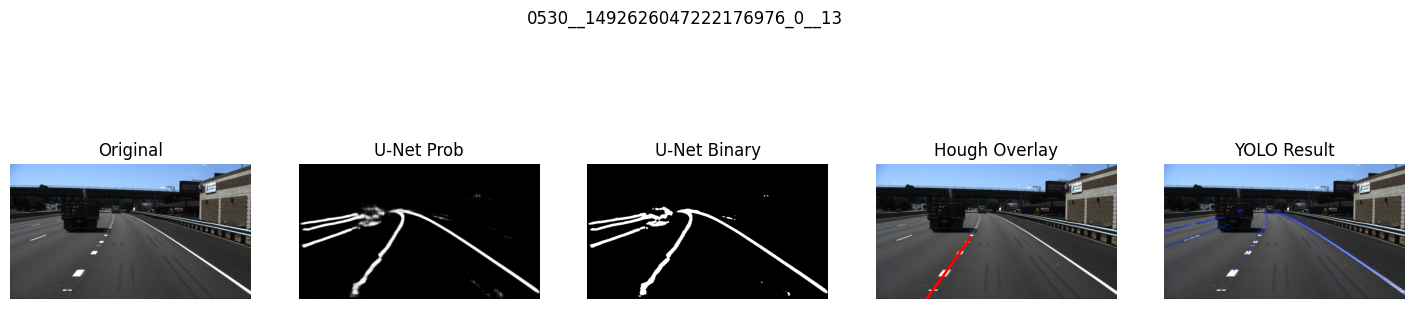

In [13]:
for orig_path in selected:
    stem = orig_path.name.replace("_orig.png", "")  # unique safe stem

    prob_path  = PROB_DIR / f"{stem}_prob.png"
    bin_path   = BIN_DIR  / f"{stem}_bin.png"
    hough_path = HOUGH_DIR / f"{stem}_bin_hough.png"  # depends how you saved it

    # If your hough file naming differs, adjust here:
    if not hough_path.exists():
        # fallback: any file starting with stem
        candidates = list(HOUGH_DIR.glob(f"{stem}*hough*.png"))
        hough_path = candidates[0] if candidates else None

    # YOLO: may not have same naming; show if exists with same stem
    yolo_path = YOLO_DIR / f"{stem}.png"
    if not yolo_path.exists():
        # try jpg
        yolo_path = YOLO_DIR / f"{stem}.jpg"
    if not yolo_path.exists():
        yolo_path = None

    orig_bgr = read_bgr(orig_path)
    prob = read_gray(prob_path) if prob_path.exists() else None
    binm = read_gray(bin_path) if bin_path.exists() else None
    hough_bgr = read_bgr(hough_path) if (hough_path and Path(hough_path).exists()) else None
    yolo_bgr = read_bgr(yolo_path) if yolo_path else None

    plt.figure(figsize=(18,4))

    plt.subplot(1,5,1)
    plt.title("Original")
    plt.imshow(bgr_to_rgb(orig_bgr)); plt.axis("off")

    plt.subplot(1,5,2)
    plt.title("U-Net Prob")
    plt.imshow(prob, cmap="gray"); plt.axis("off")

    plt.subplot(1,5,3)
    plt.title("U-Net Binary")
    plt.imshow(binm, cmap="gray"); plt.axis("off")

    plt.subplot(1,5,4)
    plt.title("Hough Overlay")
    if hough_bgr is not None:
        plt.imshow(bgr_to_rgb(hough_bgr))
    else:
        plt.text(0.1, 0.5, "Hough not found", fontsize=12)
    plt.axis("off")

    plt.subplot(1,5,5)
    plt.title("YOLO Result")
    if yolo_rgb is not None:
        plt.imshow(yolo_rgb)
    else:
        plt.text(0.1, 0.5, "YOLO not found\nfor this stem", fontsize=12)
    plt.axis("off")

    plt.suptitle(stem, y=1.05)
    plt.show()
